In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Load Dataset
df = pd.read_excel("/content/drive/MyDrive/Data_Train.xlsx")

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
# Dataset Overview
print(df.shape)

df.info()

df.describe()

(10683, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [6]:
# Data Quality Analysis
df.isnull().sum()

df.duplicated().sum()

np.int64(0)

In [5]:
# Data Cleaning
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

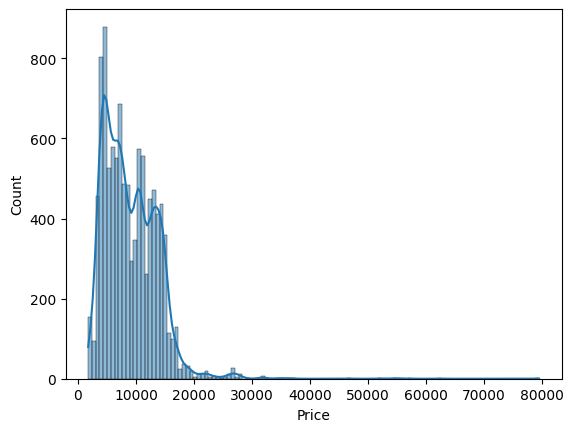

In [7]:
# Exploratory Data Analysis
# Price Distribution
sns.histplot(df["Price"], kde=True)
plt.show()

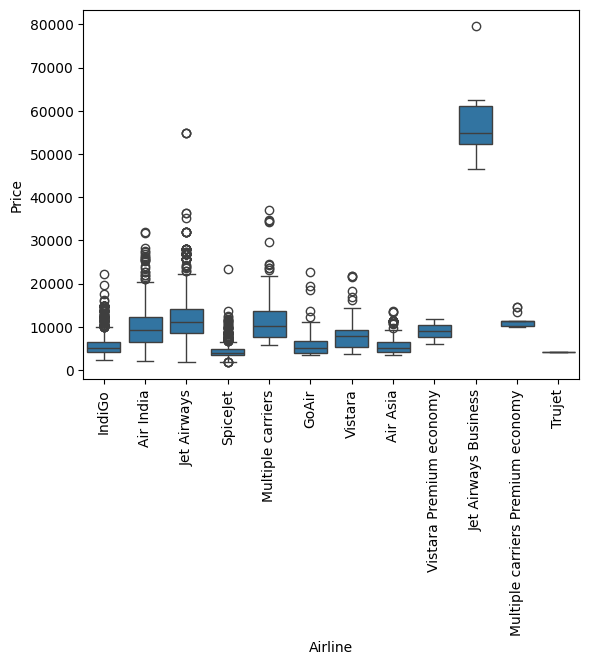

In [8]:
# Airline vs Price
sns.boxplot(
    x="Airline",
    y="Price",
    data=df
)
plt.xticks(rotation=90)
plt.show()

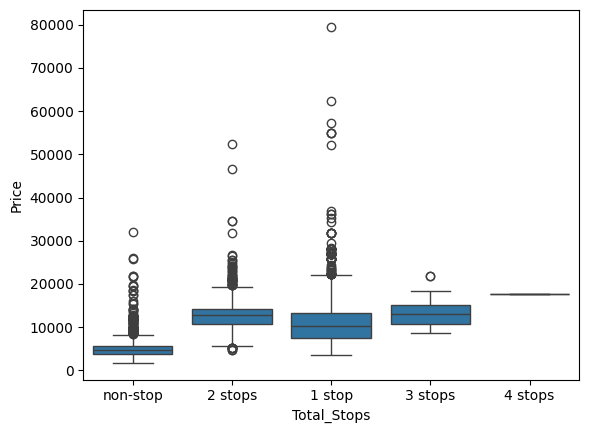

In [9]:
# Stops vs Price
sns.boxplot(
    x="Total_Stops",
    y="Price",
    data=df
)
plt.show()

In [ ]:
# Feature Engineering
# Date
df["Journey_Day"] = pd.to_datetime(
    df["Date_of_Journey"]
).dt.day

df["Journey_Month"] = pd.to_datetime(
    df["Date_of_Journey"]
).dt.month

In [ ]:
# Departure Time
df["Dep_Hour"] = pd.to_datetime(
    df["Dep_Time"]
).dt.hour

df["Dep_Min"] = pd.to_datetime(
    df["Dep_Time"]
).dt.minute

In [13]:
# Arrival Time
df["Arrival_Hour"] = pd.to_datetime(
    df["Arrival_Time"]
).dt.hour

df["Arrival_Min"] = pd.to_datetime(
    df["Arrival_Time"]
).dt.minute

In [14]:
# Duration Feature Engineering

duration = list(df["Duration"])

for i in range(len(duration)):

    # If only hours or only minutes exist
    if len(duration[i].split()) != 2:

        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"

        else:
            duration[i] = "0h " + duration[i]

duration_hours = []
duration_mins = []

for i in range(len(duration)):

    duration_hours.append(
        int(duration[i].split()[0][:-1])
    )

    duration_mins.append(
        int(duration[i].split()[1][:-1])
    )

df["Duration_Hours"] = duration_hours

df["Duration_Mins"] = duration_mins

In [15]:
df[["Duration","Duration_Hours","Duration_Mins"]].head()

,Duration,Duration_Hours,Duration_Mins
0,2h 50m,2,50
1,7h 25m,7,25
2,19h,19,0
3,5h 25m,5,25
4,4h 45m,4,45


In [16]:
# Drop Unnecessary Columns
df.drop(
    columns=[
        "Date_of_Journey",
        "Dep_Time",
        "Arrival_Time",
        "Duration",
        "Route"
    ],
    inplace=True
)

In [17]:
# Encoding
df = pd.get_dummies(
    df,
    columns=[
        'Airline',
        'Source',
        'Destination',
        'Total_Stops',
        'Additional_Info'
    ],
    drop_first=True
)

In [18]:
# Define Features and Target
X = df.drop("Price", axis=1)

y = df["Price"]

In [19]:
# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8369, 41)
(2093, 41)


In [21]:
# Baseline Neural Network
baseline_model = Sequential()

baseline_model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(41,)
    )
)

baseline_model.add(
    Dense(
        64,
        activation="relu"
    )
)

baseline_model.add(
    Dense(
        32,
        activation="relu"
    )
)

baseline_model.add(Dense(1))

In [22]:
baseline_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


In [23]:
# Train
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 84493552.0000 - mae: 7956.6338 - val_loss: 22156070.0000 - val_mae: 3592.0667
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10927916.0000 - mae: 2276.0232 - val_loss: 7690932.5000 - val_mae: 1817.5336
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7076991.0000 - mae: 1791.4965 - val_loss: 7090417.0000 - val_mae: 1727.9972
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6290022.5000 - mae: 1698.2169 - val_loss: 6701329.0000 - val_mae: 1633.8009
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5851812.5000 - mae: 1634.6976 - val_loss: 6455067.0000 - val_mae: 1597.6194
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5559746.5000 - mae: 1581.8508 - val_loss: 6270399.0000 - val_mae: 1539.8116
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5326790.0000 - mae: 1539.4326 - val_loss: 6098967.0000 - val_mae: 1504.8054
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━

In [24]:
# Baseline Evaluation
y_pred = baseline_model.predict(X_test)

y_pred = y_pred.flatten()

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [25]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(mae)
print(rmse)
print(r2)

1360.6058349609375
2203.800921136027
0.7670660018920898


In [26]:
# Experimental Analysis
# Create Experiment Function
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

experiment_results = []

def run_experiment(
        exp_name,
        hidden_layers,
        optimizer='adam',
        epochs=100,
        batch_size=32,
        dropout_rate=0):

    model = Sequential()

    model.add(
        Dense(
            hidden_layers[0],
            activation='relu',
            input_shape=(X_train.shape[1],)
        )
    )

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for neurons in hidden_layers[1:]:

        model.add(
            Dense(
                neurons,
                activation='relu'
            )
        )

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    pred = model.predict(X_test, verbose=0)

    if np.isnan(pred).any():
        print(f"{exp_name} produced NaN predictions - skipped")
        return

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    experiment_results.append([
        exp_name,
        str(hidden_layers),
        optimizer,
        epochs,
        batch_size,
        dropout_rate,
        mae,
        rmse,
        r2
    ])

In [27]:
# Run 10 Experiments
run_experiment("Exp1",[128,64,32],"adam",100,32,0)

run_experiment("Exp2",[64,32],"adam",100,32,0)

run_experiment("Exp3",[256,128,64],"adam",100,32,0)

run_experiment("Exp4",[128,64,32],"rmsprop",100,32,0)

run_experiment("Exp5",[128,64,32],"adam",100,128,0)

run_experiment("Exp6",[128,64,32],"adam",100,32,0.2)

run_experiment("Exp7",[128,64,32],"adam",100,64,0)

run_experiment("Exp8",[128,64,32],"adam",150,32,0)

run_experiment("Exp9",[256,128,64,32],"adam",100,32,0)

run_experiment("Exp10",[512,256,128,64],"adam",100,32,0.2)

In [28]:
# Experimental Results Table
experiment_df = pd.DataFrame(
    experiment_results,
    columns=[
        "Experiment",
        "Architecture",
        "Optimizer",
        "Epochs",
        "Batch_Size",
        "Dropout",
        "MAE",
        "RMSE",
        "R2"
    ]
)

experiment_df

,Experiment,Architecture,Optimizer,Epochs,Batch_Size,Dropout,MAE,RMSE,R2
0,Exp1,"[128, 64, 32]",adam,100,32,0.0,1360.739990,2218.015216,0.764051
1,Exp2,"[64, 32]",adam,100,32,0.0,1342.488281,2172.124306,0.773714
2,Exp3,"[256, 128, 64]",adam,100,32,0.0,1399.287354,2268.444401,0.753200
3,Exp4,"[128, 64, 32]",rmsprop,100,32,0.0,1371.557861,2227.203291,0.762093
4,Exp5,"[128, 64, 32]",adam,100,128,0.0,1363.613525,2187.551485,0.770488
5,Exp6,"[128, 64, 32]",adam,100,32,0.2,1395.884277,2257.986603,0.755471
6,Exp7,"[128, 64, 32]",adam,100,64,0.0,1364.587769,2194.265709,0.769077
7,Exp8,"[128, 64, 32]",adam,150,32,0.0,1373.053589,2216.014779,0.764477
8,Exp9,"[256, 128, 64, 32]",adam,100,32,0.0,1410.793335,2302.575732,0.745718
9,Exp10,"[512, 256, 128, 64]",adam,100,32,0.2,1557.359741,2445.629776,0.713140


In [29]:
# Sort Experiments by Performance
best_model_result = experiment_df.sort_values(
    by="R2",
    ascending=False
).head(1)

best_model_result

,Experiment,Architecture,Optimizer,Epochs,Batch_Size,Dropout,MAE,RMSE,R2
1,Exp2,"[64, 32]",adam,100,32,0.0,1342.488281,2172.124306,0.773714


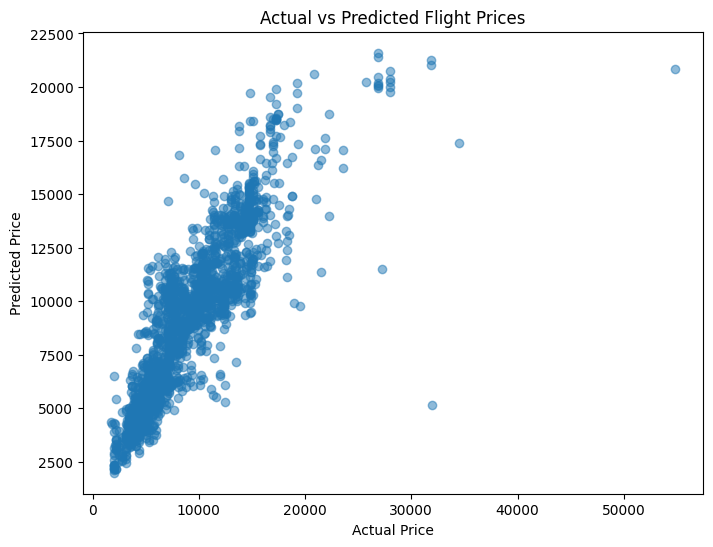

In [30]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

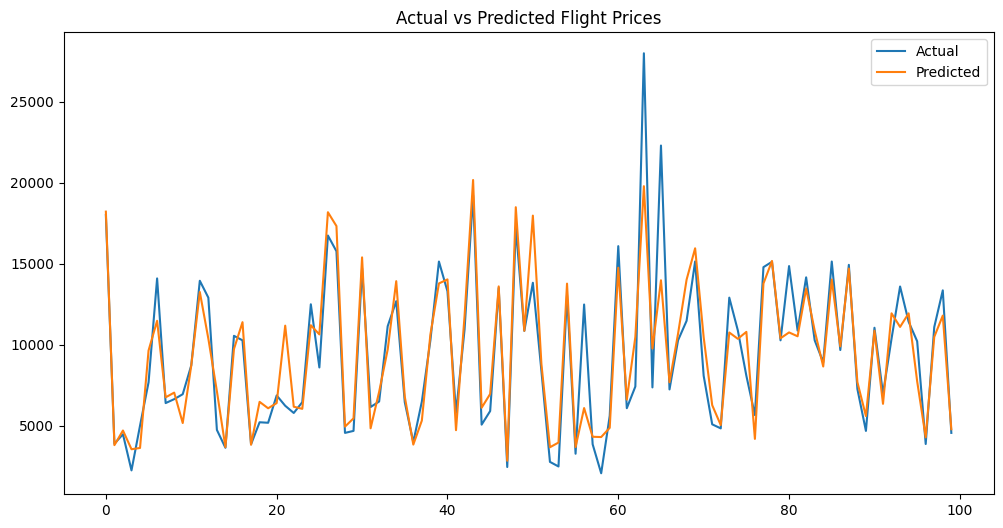

In [31]:
# Actual vs Predicted Line Plot
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison = comparison.head(100)

plt.figure(figsize=(12,6))

plt.plot(comparison["Actual"].values)

plt.plot(comparison["Predicted"].values)

plt.legend(["Actual","Predicted"])

plt.title("Actual vs Predicted Flight Prices")

plt.show()

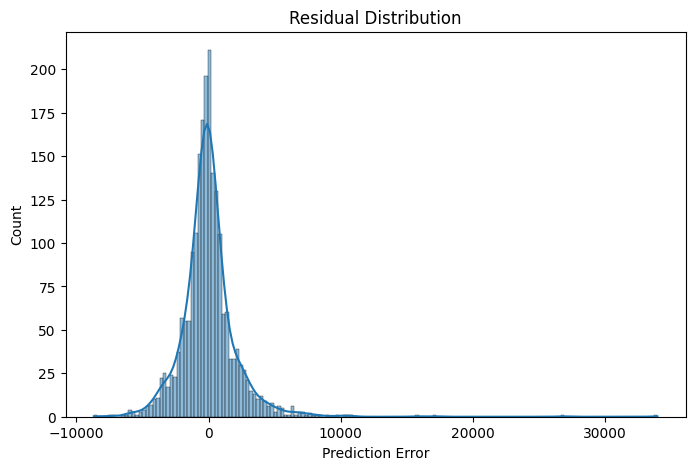

In [32]:
# Residual Distribution
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

**Model Assessment on Unseen Test Set**



The data set was partitioned into an 80:20 training and testing set. The model testing subset was not included in the model training process and is considered unseen data. The performance of the model was assessed by MAE, RMSE and R square values. The performance in terms of RMSE and R² in the unseen test set was satisfactory for the best performing neural network with a value of around 2172.12 and 0.774 respectively.

In [33]:
# Feature Importance Analysis
# Train Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [34]:
# Calculate Importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
6,Duration_Hours,0.422507
0,Journey_Day,0.094287
36,Additional_Info_In-flight meal not included,0.077423
12,Airline_Jet Airways Business,0.069312
11,Airline_Jet Airways,0.063492
1,Journey_Month,0.047619
27,Destination_New Delhi,0.029198
4,Arrival_Hour,0.026004
28,Total_Stops_2 stops,0.023076
2,Dep_Hour,0.021542


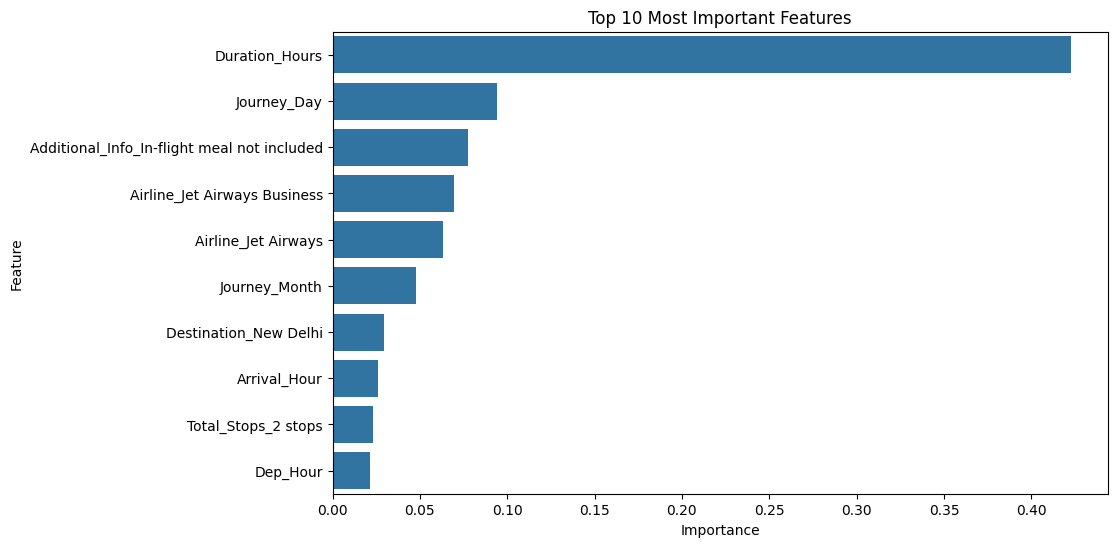

In [35]:
# Plot Importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

## Feature Importance Analysis

Feature importance analysis was performed to find the variables which contribute the most to the flight price prediction. From the results, it can be observed that the feature with the highest influence is Duration_Hours, meaning that longer flights are likely to cost more. Other significant variables are Journey_Day, Additional_Info (In-flight meal not included), Airline type and Journey_Month. The results are in line with the airline price theory, as flight duration, airline service quality, seasonality, and travel schedules are strong determinants of the airline price. The analysis enhances the interpretability of the predictive model, and can give valuable business insights into factors that influence airline ticket pricing.

## Model Explainability

Initially, neural networks are black-box models but feature importance analysis was used to improve explainability of the models. Most notable results indicated that the time of the week (Duration_Hours), the day of the week (Journey_Day), characteristics of the airlines (Airline characteristics), destination (Destination), and total stops (Total_Stops) are the most influential variables in determining the price of ticket. This offers visibility into how the model arrives at its decisions, and helps business understand pricing factors.

## Data Balancing Considerations

For the purpose of this project, there is no need to use any data balancing techniques because it is a regression problem and not a classification problem. Target variable is continuous flight prices, so it is not applicable to class imbalance.

## Strengths of the Proposed Solution

The proposed neural network model is an appropriate model to fit the complex and non-linear relationship between flight characteristics and ticket prices. The model performed well in predicting the price of the product, with an R² value of around 0.774, which indicates that the model captures a large portion of the variation in prices. The performance of the models was enhanced as a result of feature engineering. Moreover, several different experimental configurations were tested to optimize the selection of the most appropriate configuration.

## Limitations of the Proposed Solution

Contrary to popular belief, the model is strictly of a historical nature and does not and cannot take into consideration unexpected events in the market like weather delays, fluctuations in fuel prices, economic changes, global crisis, etc. However, with high priced flight tickets, outliers are making prediction more difficult to make with accuracy. In addition, neural networks are typically less interpretable than traditional machine learning models, and must be periodically retrained to ensure that their performance does not degrade.

## Business Recommendations

The results of this study suggest that airlines and travel platforms could consider implementing predictive analytics in their dynamic pricing strategies. Flight duration, airplane type, travel dates and service characteristics should be carefully monitored as they have a big impact on flight fares. Seasonal traffic intensity can be used to create the optimal promotion and pricing strategy. Lastly, predictive models can be embedded in booking systems to enhance customer experience by providing more accurate fare predictions.

## Deployment Considerations

The developed model can be deployed using frameworks such as Flask or Streamlit to provide real-time flight price predictions. The model can be used via APIs to be integrated within airline reservation systems. The training of the periodic regime is recommended, based on fresh flight data, to sustain the accuracy of the predictions. Reliable operation at varying market conditions should be obtained by carrying out continuous monitoring.

## Deployment Decision

The proposed model is recommended to be deployed based on the predictive performance and the ability to generate business value from the model. The model can be applied to dynamic pricing, to enhance revenue management and to give an accurate flight fare estimate to the customers. So this model has the potential to be used in real-life airline and travel booking systems.

## Conclusion

This project was successfully able to create the end-to-end flight price prediction system using the deep learning techniques. The data presented in this paper has been thoroughly analyzed, with data cleaning, explorative data analysis, feature engineering, encoding, scaling, and modelling of neural networks. To compare the various neural network configurations, ten different configurations were evaluated to determine the most appropriate configuration. The model with the highest performance gave a coefficient of determination of around 0.774 and proved to be very good at predicting the new samples. The flight duration and travel dates, the airline characteristics, and service-related factors have significant effects on ticket prices, as computed by feature importance analysis. Results show the feasibility of machine learning and deep learning methods for assisting airlines in revenue optimization and customer decision making. By regularly retraining the system and incorporating it into booking platforms, the proposed system can offer precise and reliable forecasts of flight fares in real-world situations.